# Vision Transformers & The Frontier of Computer Vision

## From ViT to CLIP, DINOv2, and SAM

---

In 2020, Transformers—originally designed for NLP—proved they could **match or beat CNNs** at image recognition. This notebook explores this paradigm shift and the cutting-edge models reshaping computer vision.

### The Vision Transformer Revolution

| Year | Model | Innovation | Impact |
|------|-------|-----------|--------|
| 2020 | **ViT** | Pure transformer for images | Proved transformers work for vision |
| 2021 | **CLIP** | Vision-language pretraining | Zero-shot image classification |
| 2021 | **DINO** | Self-supervised ViT | Emergent segmentation properties |
| 2023 | **DINOv2** | Scaled self-supervised learning | Best general features |
| 2023 | **SAM** | Segment Anything | Universal segmentation |
| 2024 | **SAM 2** | Video segmentation | Temporal understanding |

### What You'll Learn

| Chapter | Topic | Key Concepts |
|---------|-------|-------------|
| 1 | Attention Mechanism | Self-attention, multi-head attention |
| 2 | Vision Transformer (ViT) | Patch embeddings, position encoding |
| 3 | CLIP | Contrastive learning, zero-shot transfer |
| 4 | DINOv2 | Self-supervised learning, feature extraction |
| 5 | SAM | Promptable segmentation |
| 6 | Hybrid Architectures | ConvNeXt, Swin Transformer |
| 7 | Practical Applications | Using SOTA models |

---

*"An image is worth 16x16 words."* - ViT Paper Title

In [ ]:
# ============================================================================
#                           SETUP & IMPORTS
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple, Optional, Dict
import math
import warnings
warnings.filterwarnings('ignore')

# Beautiful plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

PyTorch Version: 2.10.0+cu128
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


---

# Chapter 1: The Attention Mechanism

## The Core Innovation Behind Transformers

Attention allows the model to focus on relevant parts of the input:

### Self-Attention Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where:
- **Q** (Query): "What am I looking for?"
- **K** (Key): "What do I contain?"
- **V** (Value): "What information do I provide?"
- **d_k**: Dimension of keys (for scaling)

```
    Input tokens: [CLS] [patch1] [patch2] ... [patchN]
                    |      |       |           |
                    v      v       v           v
                   Q,K,V  Q,K,V   Q,K,V      Q,K,V
                    \      |       |          /
                     \     |       |         /
                      ──── ATTENTION ──────
                            |
                    Every token can attend
                    to every other token!
```

In [ ]:
# ============================================================================
#                    SCALED DOT-PRODUCT ATTENTION
# ============================================================================

print("="*60)
print("           SCALED DOT-PRODUCT ATTENTION")
print("="*60)

def scaled_dot_product_attention(
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    mask: Optional[torch.Tensor] = None
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Compute scaled dot-product attention.

    Args:
        query: (batch, seq_len, d_k)
        key: (batch, seq_len, d_k)
        value: (batch, seq_len, d_v)
        mask: Optional attention mask

    Returns:
        output: (batch, seq_len, d_v)
        attention_weights: (batch, seq_len, seq_len)
    """
    d_k = query.size(-1)

    # Step 1: Compute attention scores
    # Q @ K^T / sqrt(d_k)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    # Step 2: Apply mask (if provided)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # Step 3: Softmax to get attention weights
    attention_weights = F.softmax(scores, dim=-1)

    # Step 4: Multiply by values
    output = torch.matmul(attention_weights, value)

    return output, attention_weights


# Example
batch_size = 2
seq_len = 4
d_k = 8

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"\nInput shapes:")
print(f"  Query: {Q.shape}")
print(f"  Key:   {K.shape}")
print(f"  Value: {V.shape}")
print(f"\nOutput shapes:")
print(f"  Output:     {output.shape}")
print(f"  Attention:  {attn_weights.shape}")
print(f"\nAttention weights (first batch):")
print(attn_weights[0].detach().numpy().round(3))
print(f"\n Each row sums to 1: {attn_weights[0].sum(dim=-1).tolist()}")

           SCALED DOT-PRODUCT ATTENTION

Input shapes:
  Query: torch.Size([2, 4, 8])
  Key:   torch.Size([2, 4, 8])
  Value: torch.Size([2, 4, 8])

Output shapes:
  Output:     torch.Size([2, 4, 8])
  Attention:  torch.Size([2, 4, 4])

Attention weights (first batch):
[[0.509 0.316 0.111 0.063]
 [0.262 0.383 0.177 0.178]
 [0.244 0.024 0.201 0.53 ]
 [0.745 0.108 0.035 0.112]]

 Each row sums to 1: [1.0, 1.0, 1.0, 1.0000001192092896]


In [ ]:
# ============================================================================
#                    MULTI-HEAD ATTENTION
# ============================================================================

print("="*60)
print("              MULTI-HEAD ATTENTION")
print("="*60)

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention.

    Instead of one attention function, use h parallel attention "heads":
    - Each head learns different attention patterns
    - Outputs are concatenated and projected

    MultiHead(Q, K, V) = Concat(head_1, ..., head_h) @ W_O
    where head_i = Attention(Q @ W_Q^i, K @ W_K^i, V @ W_V^i)

    Visualization:

        Input (d_model)
            |
    +-------+-------+-------+
    |       |       |       |
    Head1   Head2   Head3  Head4  (h heads, each d_k = d_model/h)
    |       |       |       |
    +-------+-------+-------+
            |
        Concat
            |
        Linear (W_O)
            |
        Output (d_model)
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Output projection
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size = query.size(0)

        # 1. Linear projections
        Q = self.W_q(query)  # (batch, seq_len, d_model)
        K = self.W_k(key)
        V = self.W_v(value)

        # 2. Reshape to (batch, num_heads, seq_len, d_k)
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 3. Attention
        output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # 4. Reshape back and project
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(output)
        output = self.dropout(output)

        return output, attn_weights


# Test
mha = MultiHeadAttention(d_model=64, num_heads=8)
x = torch.randn(2, 16, 64)  # (batch, seq_len, d_model)

output, attn = mha(x, x, x)  # Self-attention: Q=K=V

print(f"\nMulti-Head Attention:")
print(f"  Input:  {x.shape}")
print(f"  Output: {output.shape}")
print(f"  Attention weights: {attn.shape} (batch, heads, seq, seq)")
print(f"  Parameters: {sum(p.numel() for p in mha.parameters()):,}")

              MULTI-HEAD ATTENTION

Multi-Head Attention:
  Input:  torch.Size([2, 16, 64])
  Output: torch.Size([2, 16, 64])
  Attention weights: torch.Size([2, 8, 16, 16]) (batch, heads, seq, seq)
  Parameters: 16,640


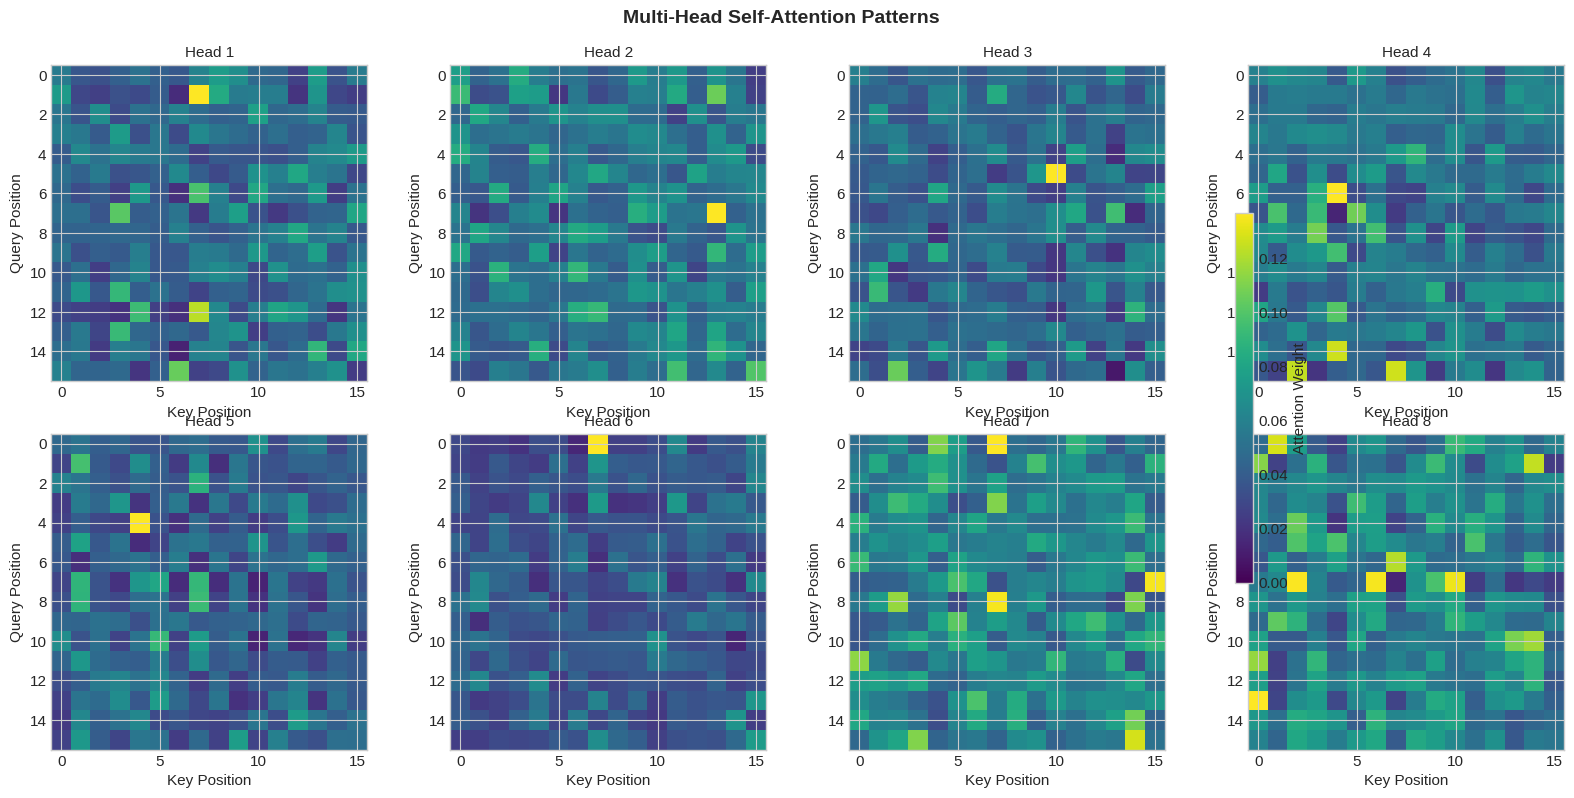


 Different heads learn different patterns:
 - Some focus on nearby positions
 - Some focus on specific patterns
 - Together they capture diverse relationships


In [ ]:
# ============================================================================
#                    VISUALIZE ATTENTION PATTERNS
# ============================================================================

def visualize_attention(attn_weights, title="Attention Weights"):
    """
    Visualize attention patterns from multiple heads.
    """
    num_heads = attn_weights.size(1)
    attn = attn_weights[0].detach().cpu().numpy()  # First batch

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i, ax in enumerate(axes.flatten()):
        if i < num_heads:
            im = ax.imshow(attn[i], cmap='viridis', vmin=0)
            ax.set_title(f'Head {i+1}', fontsize=11)
            ax.set_xlabel('Key Position')
            ax.set_ylabel('Query Position')
        else:
            ax.axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=axes, shrink=0.6, label='Attention Weight')
    plt.tight_layout()
    plt.show()


visualize_attention(attn, "Multi-Head Self-Attention Patterns")

print("\n Different heads learn different patterns:")
print(" - Some focus on nearby positions")
print(" - Some focus on specific patterns")
print(" - Together they capture diverse relationships")

---

# Chapter 2: Vision Transformer (ViT)

## An Image is Worth 16x16 Words

ViT treats an image as a sequence of patches:

```
Original Image (224x224)           Patches (14x14 = 196 patches)
                                   Each 16x16 pixels
+------------------------+         +--+--+--+--+--+--+
|                        |         |1 |2 |3 |4 |...|14|
|                        |         +--+--+--+--+--+--+
|       Image            |   →     |15|16|..          |
|                        |         +--+--+            |
|                        |         |                  |
+------------------------+         +------------------+

Then: [CLS] + [patch_1] + [patch_2] + ... + [patch_196] + [POS]
        ↓
    Transformer Encoder
        ↓
    [CLS] token → Classification
```

In [ ]:
# ============================================================================
#                    PATCH EMBEDDING
# ============================================================================

print("="*60)
print("               PATCH EMBEDDING")
print("="*60)

class PatchEmbedding(nn.Module):
    """
    Convert image to sequence of patch embeddings.

    Two approaches:
    1. Reshape + Linear: Flatten each patch, apply linear projection
    2. Conv2d: Use conv with kernel_size=stride=patch_size (more efficient!)

    We use the Conv2d approach.
    """

    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 16,
        in_channels: int = 3,
        embed_dim: int = 768
    ):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Conv2d acts as linear projection of flattened patches
        # kernel_size = stride = patch_size means non-overlapping patches
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, channels, height, width)
        # → (batch, embed_dim, num_patches_h, num_patches_w)
        x = self.projection(x)

        # Flatten spatial dimensions: (batch, embed_dim, num_patches)
        x = x.flatten(2)

        # Transpose to (batch, num_patches, embed_dim)
        x = x.transpose(1, 2)

        return x


# Test
patch_embed = PatchEmbedding(img_size=224, patch_size=16, embed_dim=768)
x = torch.randn(2, 3, 224, 224)
patches = patch_embed(x)

print(f"\nPatch Embedding:")
print(f"  Image size:   224x224")
print(f"  Patch size:   16x16")
print(f"  Num patches:  {patch_embed.num_patches} ({224//16}x{224//16})")
print(f"  Embed dim:    768")
print(f"\n  Input:  {x.shape}")
print(f"  Output: {patches.shape}")

               PATCH EMBEDDING

Patch Embedding:
  Image size:   224x224
  Patch size:   16x16
  Num patches:  196 (14x14)
  Embed dim:    768

  Input:  torch.Size([2, 3, 224, 224])
  Output: torch.Size([2, 196, 768])


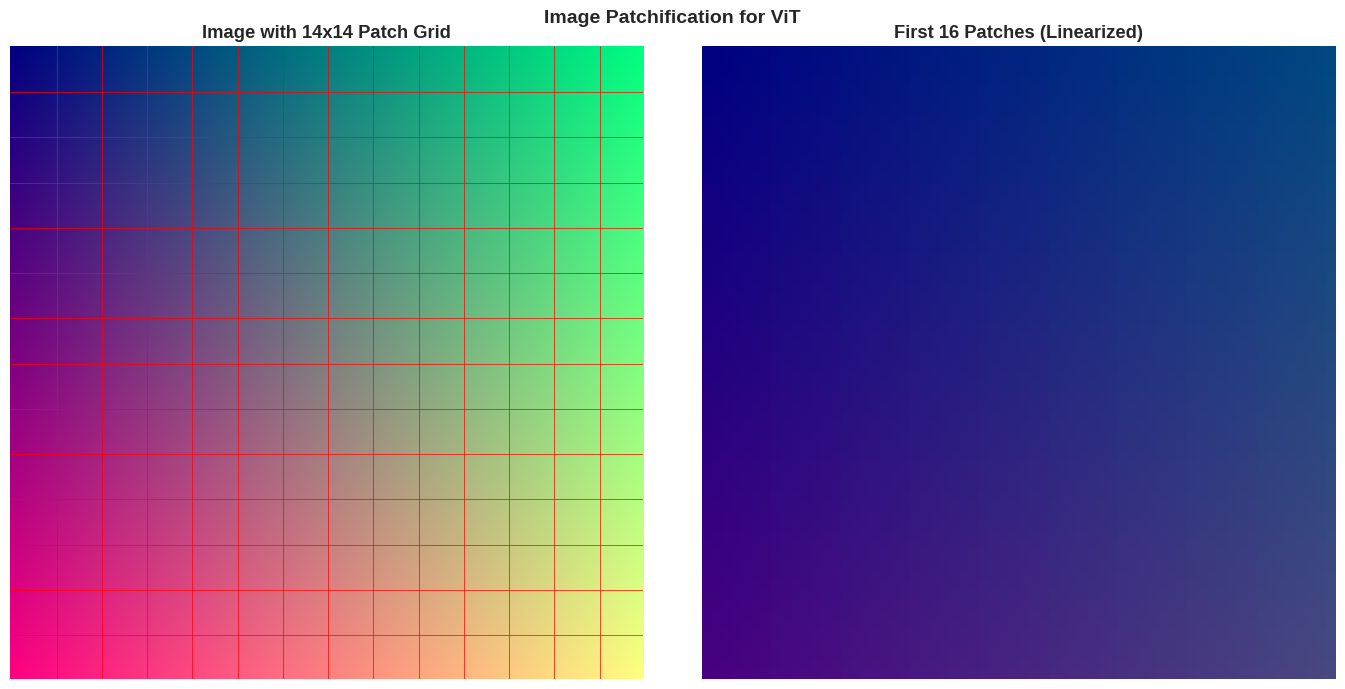

In [ ]:
# ============================================================================
#                    VISUALIZE PATCH EMBEDDING
# ============================================================================

def visualize_patches(img_tensor, patch_size=16):
    """
    Visualize how an image is split into patches.
    """
    # Create a sample image with a pattern
    img = img_tensor[0].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # Normalize for display

    h, w = img.shape[:2]
    n_patches_h = h // patch_size
    n_patches_w = w // patch_size

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Original with grid
    axes[0].imshow(img)
    for i in range(1, n_patches_h):
        axes[0].axhline(y=i*patch_size, color='red', linewidth=0.5)
    for j in range(1, n_patches_w):
        axes[0].axvline(x=j*patch_size, color='red', linewidth=0.5)
    axes[0].set_title(f'Image with {n_patches_h}x{n_patches_w} Patch Grid', fontweight='bold')
    axes[0].axis('off')

    # Show some individual patches
    patches_to_show = 16
    patch_grid = int(np.sqrt(patches_to_show))

    combined = []
    for i in range(patch_grid):
        row = []
        for j in range(patch_grid):
            patch = img[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            row.append(patch)
        combined.append(np.hstack(row))
    combined = np.vstack(combined)

    axes[1].imshow(combined)
    axes[1].set_title(f'First {patches_to_show} Patches (Linearized)', fontweight='bold')
    axes[1].axis('off')

    plt.suptitle('Image Patchification for ViT', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Create a sample image with gradients and patterns
sample_img = torch.zeros(1, 3, 224, 224)
for i in range(224):
    for j in range(224):
        sample_img[0, 0, i, j] = i / 224  # Red gradient vertical
        sample_img[0, 1, i, j] = j / 224  # Green gradient horizontal
        sample_img[0, 2, i, j] = 0.5      # Blue constant

visualize_patches(sample_img, patch_size=16)

In [ ]:
# ============================================================================
#                    TRANSFORMER ENCODER BLOCK
# ============================================================================

class TransformerEncoderBlock(nn.Module):
    """
    Single Transformer Encoder Block.

    Structure (Pre-Norm variant used in ViT):

        x
        |
        +-----> LayerNorm -> MultiHeadAttention -> Dropout -> (+)
        |                                                      |
        +------------------------------------------------------+
        |
        +-----> LayerNorm -> MLP (FFN) -> Dropout -> (+)
        |                                             |
        +---------------------------------------------+
        |
        Output

    MLP: Linear(d_model, d_ffn) -> GELU -> Linear(d_ffn, d_model)
    """

    def __init__(
        self,
        d_model: int = 768,
        num_heads: int = 12,
        mlp_ratio: float = 4.0,
        dropout: float = 0.1
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)

        self.norm2 = nn.LayerNorm(d_model)
        d_ffn = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ffn),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ffn, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Self-attention with residual
        attn_out, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + attn_out

        # MLP with residual
        x = x + self.mlp(self.norm2(x))

        return x


# Test
block = TransformerEncoderBlock(d_model=768, num_heads=12)
x = torch.randn(2, 197, 768)  # (batch, seq_len, d_model)
y = block(x)

print(f"\nTransformer Encoder Block:")
print(f"  Input:  {x.shape}")
print(f"  Output: {y.shape}")
print(f"  Parameters: {sum(p.numel() for p in block.parameters()):,}")


Transformer Encoder Block:
  Input:  torch.Size([2, 197, 768])
  Output: torch.Size([2, 197, 768])
  Parameters: 7,087,872


In [ ]:
# ============================================================================
#                    COMPLETE VISION TRANSFORMER
# ============================================================================

class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) for image classification.

    Complete architecture:

        Input Image (3, 224, 224)
            |
        Patch Embedding → (batch, 196, 768)
            |
        + [CLS] token → (batch, 197, 768)
            |
        + Position Embedding
            |
        Dropout
            |
        Transformer Encoder × 12
            |
        LayerNorm
            |
        [CLS] token only
            |
        MLP Head → num_classes
    """

    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 16,
        in_channels: int = 3,
        num_classes: int = 1000,
        d_model: int = 768,
        num_layers: int = 12,
        num_heads: int = 12,
        mlp_ratio: float = 4.0,
        dropout: float = 0.1
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, d_model)
        num_patches = self.patch_embed.num_patches

        # Learnable [CLS] token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        # Learnable position embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))

        self.dropout = nn.Dropout(dropout)

        # Transformer encoder layers
        self.encoder = nn.Sequential(*[
            TransformerEncoderBlock(d_model, num_heads, mlp_ratio, dropout)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        # Classification head
        self.head = nn.Linear(d_model, num_classes)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)

        # Patch embedding
        x = self.patch_embed(x)  # (batch, num_patches, d_model)

        # Prepend [CLS] token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (batch, num_patches+1, d_model)

        # Add position embeddings
        x = x + self.pos_embed
        x = self.dropout(x)

        # Transformer encoder
        x = self.encoder(x)
        x = self.norm(x)

        # Use [CLS] token for classification
        cls_output = x[:, 0]

        # Classification head
        return self.head(cls_output)


# Create ViT-Base
vit = VisionTransformer(
    img_size=224,
    patch_size=16,
    num_classes=1000,
    d_model=768,
    num_layers=12,
    num_heads=12
)

# Test
x = torch.randn(2, 3, 224, 224)
y = vit(x)

print("\n" + "="*60)
print("           VISION TRANSFORMER (ViT-Base)")
print("="*60)
print(f"\nArchitecture:")
print(f"  Image size:    224x224")
print(f"  Patch size:    16x16")
print(f"  Num patches:   196")
print(f"  Hidden dim:    768")
print(f"  Num layers:    12")
print(f"  Num heads:     12")
print(f"  MLP dim:       3072 (768 × 4)")
print(f"\nInput:  {x.shape}")
print(f"Output: {y.shape}")
print(f"\nTotal Parameters: {sum(p.numel() for p in vit.parameters()):,}")


           VISION TRANSFORMER (ViT-Base)

Architecture:
  Image size:    224x224
  Patch size:    16x16
  Num patches:   196
  Hidden dim:    768
  Num layers:    12
  Num heads:     12
  MLP dim:       3072 (768 × 4)

Input:  torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 1000])

Total Parameters: 86,567,656


In [ ]:
# ============================================================================
#                    ViT VARIANTS COMPARISON
# ============================================================================

print("\nViT Model Variants:")
print("="*70)

vit_configs = {
    'ViT-Ti': {'d_model': 192, 'layers': 12, 'heads': 3},
    'ViT-S': {'d_model': 384, 'layers': 12, 'heads': 6},
    'ViT-B': {'d_model': 768, 'layers': 12, 'heads': 12},
    'ViT-L': {'d_model': 1024, 'layers': 24, 'heads': 16},
    'ViT-H': {'d_model': 1280, 'layers': 32, 'heads': 16},
}

print(f"{'Model':<10} {'Hidden':<10} {'Layers':<10} {'Heads':<10} {'Params':<15}")
print("-"*55)

for name, cfg in vit_configs.items():
    model = VisionTransformer(
        d_model=cfg['d_model'],
        num_layers=cfg['layers'],
        num_heads=cfg['heads'],
        num_classes=1000
    )
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:<10} {cfg['d_model']:<10} {cfg['layers']:<10} {cfg['heads']:<10} {params:>12,}")

print("\n Note: ViT requires large datasets (ImageNet-21k) for training from scratch.")
print(" For smaller datasets, use pretrained models!")


ViT Model Variants:
Model      Hidden     Layers     Heads      Params         
-------------------------------------------------------
ViT-Ti     192        12         3             5,717,416
ViT-S      384        12         6            22,050,664
ViT-B      768        12         12           86,567,656
ViT-L      1024       24         16          304,326,632
ViT-H      1280       32         16          632,199,400

 Note: ViT requires large datasets (ImageNet-21k) for training from scratch.
 For smaller datasets, use pretrained models!


---

# Chapter 3: CLIP - Vision-Language Pretraining

## Learning Visual Concepts from Natural Language

CLIP (Contrastive Language-Image Pre-training) learns to connect images and text:

```
Image Encoder              Text Encoder
(ViT or ResNet)            (Transformer)
    ↓                          ↓
Image Embedding           Text Embedding
    [I1, I2, I3, ...]         [T1, T2, T3, ...]
         \                    /
          \                  /
           Contrastive Loss
           (match pairs!)

Training: 400M image-text pairs from the internet!
```

### Zero-Shot Classification

CLIP can classify images into ANY category without training:
1. Encode class names as text: "a photo of a dog", "a photo of a cat"
2. Encode input image
3. Find most similar text embedding

In [ ]:
# ============================================================================
#                    USING CLIP FOR ZERO-SHOT
# ============================================================================

print("="*60)
print("           CLIP ZERO-SHOT CLASSIFICATION")
print("="*60)

# Note: This requires installing the clip package
# pip install git+https://github.com/openai/CLIP.git

try:
    import clip

    # Load CLIP model
    clip_model, preprocess = clip.load('ViT-B/32', device=device)

    print(f"\nCLIP Model Loaded: ViT-B/32")
    print(f"Image input size: 224x224")

    # Example: Zero-shot classification
    # Create a simple test image (in practice, use real images)
    test_image = torch.randn(1, 3, 224, 224).to(device)

    # Define class names
    class_names = ['dog', 'cat', 'car', 'airplane', 'bird', 'tree']
    text_prompts = [f"a photo of a {name}" for name in class_names]

    # Tokenize text
    text_tokens = clip.tokenize(text_prompts).to(device)

    # Get embeddings
    with torch.no_grad():
        image_features = clip_model.encode_image(test_image)
        text_features = clip_model.encode_text(text_tokens)

        # Normalize
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Compute similarity
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

    print(f"\nZero-shot predictions:")
    for i, (name, prob) in enumerate(zip(class_names, similarity[0])):
        print(f"  {name}: {prob.item()*100:.2f}%")

except ImportError:
    print("\n CLIP not installed. Install with:")
    print("   pip install git+https://github.com/openai/CLIP.git")
    print("\n Showing conceptual code instead...")

    print("""
# CLIP Usage Example:

import clip
import torch
from PIL import Image

# Load model
model, preprocess = clip.load('ViT-B/32', device='cuda')

# Load and preprocess image
image = preprocess(Image.open('image.jpg')).unsqueeze(0).to('cuda')

# Define classes (any text!)
text = clip.tokenize(['a dog', 'a cat', 'a bird']).to('cuda')

# Get predictions
with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)

    # Cosine similarity
    similarity = (image_features @ text_features.T).softmax(dim=-1)

print(f"Predictions: {similarity}")
""")

           CLIP ZERO-SHOT CLASSIFICATION

 CLIP not installed. Install with:
   pip install git+https://github.com/openai/CLIP.git

 Showing conceptual code instead...

# CLIP Usage Example:

import clip
import torch
from PIL import Image

# Load model
model, preprocess = clip.load('ViT-B/32', device='cuda')

# Load and preprocess image
image = preprocess(Image.open('image.jpg')).unsqueeze(0).to('cuda')

# Define classes (any text!)
text = clip.tokenize(['a dog', 'a cat', 'a bird']).to('cuda')

# Get predictions
with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    
    # Cosine similarity
    similarity = (image_features @ text_features.T).softmax(dim=-1)
    
print(f"Predictions: {similarity}")



---

# Chapter 4: DINOv2 - Self-Supervised Visual Features

## Learning Without Labels

DINOv2 (Self-DIstillation with NO labels v2) learns powerful visual features through self-supervised learning:

```
      Image
        |
    +---+---+
    |       |
  Global  Local
  Crops   Crops
    |       |
    v       v
 Teacher  Student
 (EMA)    (trained)
    |       |
    +---+---+
        |
   Match outputs!
```

### Why DINOv2?

- **No labels needed**: Learns from 142M images without annotations
- **Universal features**: Works for classification, segmentation, depth, etc.
- **Emergent properties**: Automatically learns object boundaries

In [ ]:
# ============================================================================
#                    USING DINOv2
# ============================================================================

print("="*60)
print("                  DINOv2")
print("="*60)

# DINOv2 is available through torch.hub
print("\nLoading DINOv2...")

try:
    # Load DINOv2 model
    dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    dinov2 = dinov2.to(device)
    dinov2.eval()

    print(f"\nDINOv2-S/14 loaded!")
    print(f"Patch size: 14x14")
    print(f"Hidden dim: 384")

    # Extract features
    x = torch.randn(1, 3, 224, 224).to(device)

    with torch.no_grad():
        # Get [CLS] token feature (global)
        features = dinov2(x)

        # Get patch tokens (local features)
        patch_features = dinov2.forward_features(x)['x_norm_patchtokens']

    print(f"\nFeature shapes:")
    print(f"  Global (CLS): {features.shape}")
    print(f"  Patch tokens: {patch_features.shape}")

except Exception as e:
    print(f"\n Could not load DINOv2: {e}")
    print("\n Showing usage example instead...")

    print("""
# DINOv2 Usage:

import torch

# Load model (S, B, L, or G variants)
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2.eval()

# Prepare image (standard ImageNet preprocessing)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img = transform(Image.open('image.jpg')).unsqueeze(0)

# Extract features
with torch.no_grad():
    features = dinov2(img)  # [1, 384] for ViT-S

# Use for downstream tasks (classification, retrieval, etc.)
""")

                  DINOv2

Loading DINOv2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 401MB/s]



DINOv2-S/14 loaded!
Patch size: 14x14
Hidden dim: 384

Feature shapes:
  Global (CLS): torch.Size([1, 384])
  Patch tokens: torch.Size([1, 256, 384])


In [ ]:
# ============================================================================
#                    DINOv2 MODEL VARIANTS
# ============================================================================

print("\nDINOv2 Model Variants:")
print("="*70)

dinov2_models = [
    ('dinov2_vits14', 'ViT-S/14', 22, 384, '22M'),
    ('dinov2_vitb14', 'ViT-B/14', 86, 768, '86M'),
    ('dinov2_vitl14', 'ViT-L/14', 300, 1024, '300M'),
    ('dinov2_vitg14', 'ViT-G/14', 1100, 1536, '1.1B'),
]

print(f"{'Model ID':<20} {'Architecture':<12} {'Params':<10} {'Dim':<8}")
print("-"*55)
for model_id, arch, params, dim, params_str in dinov2_models:
    print(f"{model_id:<20} {arch:<12} {params_str:<10} {dim:<8}")

print("\n DINOv2 Features:")
print(" - Trained on 142M images (LVD-142M dataset)")
print(" - Self-supervised: no labels needed!")
print(" - Works for: classification, segmentation, depth, matching")
print(" - Emergent properties: learns object boundaries automatically")


DINOv2 Model Variants:
Model ID             Architecture Params     Dim     
-------------------------------------------------------
dinov2_vits14        ViT-S/14     22M        384     
dinov2_vitb14        ViT-B/14     86M        768     
dinov2_vitl14        ViT-L/14     300M       1024    
dinov2_vitg14        ViT-G/14     1.1B       1536    

 DINOv2 Features:
 - Trained on 142M images (LVD-142M dataset)
 - Self-supervised: no labels needed!
 - Works for: classification, segmentation, depth, matching
 - Emergent properties: learns object boundaries automatically


---

# Chapter 5: SAM - Segment Anything Model

## Universal Segmentation

SAM can segment ANY object in ANY image with just a point, box, or text prompt:

```
      Image                    Prompts
        |                         |
        v                         v
   Image Encoder            Prompt Encoder
   (ViT-H/14)              (point/box/mask)
        |                         |
        +------------+------------+
                     |
              Mask Decoder
              (lightweight)
                     |
                     v
              Segmentation Mask
```

In [ ]:
# ============================================================================
#                    SEGMENT ANYTHING MODEL (SAM)
# ============================================================================

print("="*60)
print("           SEGMENT ANYTHING MODEL (SAM)")
print("="*60)

print("""
SAM Architecture:

1. IMAGE ENCODER (runs once per image)
   - ViT-H/16 with 632M parameters
   - Produces 64x64 image embedding

2. PROMPT ENCODER (flexible input)
   - Points: (x, y, foreground/background)
   - Boxes: (x1, y1, x2, y2)
   - Masks: coarse mask hint
   - Text: through CLIP (SAM 2)

3. MASK DECODER (runs per prompt)
   - Two-way transformer
   - Outputs 3 mask options + quality scores

SAM Variants:
"""
)

sam_models = [
    ('SAM-ViT-B', 'ViT-B', '91M', 'Fast, good quality'),
    ('SAM-ViT-L', 'ViT-L', '308M', 'Better quality'),
    ('SAM-ViT-H', 'ViT-H', '636M', 'Best quality'),
    ('SAM 2', 'Hiera', '~600M', 'Video + image, faster'),
]

print(f"{'Model':<15} {'Backbone':<10} {'Params':<10} {'Notes'}")
print("-"*60)
for model, backbone, params, notes in sam_models:
    print(f"{model:<15} {backbone:<10} {params:<10} {notes}")

           SEGMENT ANYTHING MODEL (SAM)

SAM Architecture:

1. IMAGE ENCODER (runs once per image)
   - ViT-H/16 with 632M parameters
   - Produces 64x64 image embedding

2. PROMPT ENCODER (flexible input)
   - Points: (x, y, foreground/background)
   - Boxes: (x1, y1, x2, y2)
   - Masks: coarse mask hint
   - Text: through CLIP (SAM 2)

3. MASK DECODER (runs per prompt)
   - Two-way transformer
   - Outputs 3 mask options + quality scores

SAM Variants:

Model           Backbone   Params     Notes
------------------------------------------------------------
SAM-ViT-B       ViT-B      91M        Fast, good quality
SAM-ViT-L       ViT-L      308M       Better quality
SAM-ViT-H       ViT-H      636M       Best quality
SAM 2           Hiera      ~600M      Video + image, faster


In [ ]:
# ============================================================================
#                    SAM USAGE EXAMPLE
# ============================================================================

print("\nSAM Usage Example:")
print("="*60)

print("""
# Installation:
pip install segment-anything

# Usage:
from segment_anything import sam_model_registry, SamPredictor
import cv2

# Load model
sam = sam_model_registry['vit_h'](checkpoint='sam_vit_h_4b8939.pth')
sam.to(device='cuda')

# Create predictor
predictor = SamPredictor(sam)

# Load and set image (encodes once)
image = cv2.imread('image.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
predictor.set_image(image)

# Segment with point prompt
input_point = np.array([[500, 375]])  # (x, y)
input_label = np.array([1])  # 1 = foreground

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True  # Returns 3 masks
)

# Best mask
best_mask = masks[scores.argmax()]

# Segment with box prompt
input_box = np.array([100, 100, 400, 400])  # x1, y1, x2, y2
masks, _, _ = predictor.predict(box=input_box)
""")

print("\n SAM Key Features:")
print(" - Zero-shot: Works on any image without training")
print(" - Interactive: Refine with additional prompts")
print(" - Multiple outputs: Returns 3 masks with confidence scores")
print(" - Automatic mode: Can segment everything in an image")


SAM Usage Example:

# Installation:
pip install segment-anything

# Usage:
from segment_anything import sam_model_registry, SamPredictor
import cv2

# Load model
sam = sam_model_registry['vit_h'](checkpoint='sam_vit_h_4b8939.pth')
sam.to(device='cuda')

# Create predictor
predictor = SamPredictor(sam)

# Load and set image (encodes once)
image = cv2.imread('image.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
predictor.set_image(image)

# Segment with point prompt
input_point = np.array([[500, 375]])  # (x, y)
input_label = np.array([1])  # 1 = foreground

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True  # Returns 3 masks
)

# Best mask
best_mask = masks[scores.argmax()]

# Segment with box prompt
input_box = np.array([100, 100, 400, 400])  # x1, y1, x2, y2
masks, _, _ = predictor.predict(box=input_box)


 SAM Key Features:
 - Zero-shot: Works on any image without training
 - Interactive: Refine wit

---

# Chapter 6: Hybrid Architectures

## Best of Both Worlds: CNNs + Transformers

| Architecture | Key Innovation | Advantage |
|-------------|----------------|----------|
| **ConvNeXt** | Modernized ResNet | Fast, simple, competitive |
| **Swin Transformer** | Shifted windows | Linear complexity |
| **CoAtNet** | Conv stems + attention | Best of both |
| **MaxViT** | Multi-axis attention | Global + local efficiently |

In [ ]:
# ============================================================================
#                    ConvNeXt - A CONVNET FOR THE 2020s
# ============================================================================

print("="*60)
print("      ConvNeXt - A CONVNET FOR THE 2020s")
print("="*60)

print("""
ConvNeXt: Modernizing ResNet with Transformer insights

Key modifications:
1. Patchify stem: 4x4 conv, stride 4 (like ViT)
2. Inverted bottleneck: expand → depthwise → project
3. Larger kernels: 7x7 depthwise convs
4. Fewer activations: only one GELU per block
5. Fewer norms: only one LayerNorm per block
6. Separate downsampling: explicit downsample layers

Result: Matches or beats Swin Transformer!

ConvNeXt Block:
    x
    |
    DwConv 7x7
    |
    LayerNorm
    |
    Linear (expand 4x)
    |
    GELU
    |
    Linear (project)
    |
    + x (residual)
""")

# Using torchvision's ConvNeXt
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
params = sum(p.numel() for p in convnext.parameters())

print(f"\nConvNeXt-Tiny:")
print(f"  Parameters: {params:,}")
print(f"  Top-1 Accuracy: 82.5% (ImageNet)")

# Test
x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    y = convnext(x)
print(f"\n  Input: {x.shape}")
print(f"  Output: {y.shape}")

      ConvNeXt - A CONVNET FOR THE 2020s

ConvNeXt: Modernizing ResNet with Transformer insights

Key modifications:
1. Patchify stem: 4x4 conv, stride 4 (like ViT)
2. Inverted bottleneck: expand → depthwise → project
3. Larger kernels: 7x7 depthwise convs
4. Fewer activations: only one GELU per block
5. Fewer norms: only one LayerNorm per block
6. Separate downsampling: explicit downsample layers

Result: Matches or beats Swin Transformer!

ConvNeXt Block:
    x
    |
    DwConv 7x7
    |
    LayerNorm
    |
    Linear (expand 4x)
    |
    GELU
    |
    Linear (project)
    |
    + x (residual)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 234MB/s] 



ConvNeXt-Tiny:
  Parameters: 28,589,128
  Top-1 Accuracy: 82.5% (ImageNet)

  Input: torch.Size([1, 3, 224, 224])
  Output: torch.Size([1, 1000])


In [ ]:
# ============================================================================
#                    SWIN TRANSFORMER
# ============================================================================

print("="*60)
print("              SWIN TRANSFORMER")
print("="*60)

print("""
Swin Transformer: Hierarchical Vision Transformer

Key innovations:
1. Hierarchical structure (like CNNs)
2. Window-based attention (local, efficient)
3. Shifted windows (cross-window connections)

Regular ViT: Attention over ALL patches = O(n²)
Swin:        Attention within windows = O(n)

Window Attention:
+---+---+---+---+
| W | W | W | W |   W = attention within window
+---+---+---+---+
| W | W | W | W |   No cross-window attention
+---+---+---+---+

Shifted Window Attention:
  +---+---+---+---+
  | W | W | W | W |   Windows shifted by (M/2, M/2)
  +---+---+---+---+   Creates cross-window connections!
  | W | W | W | W |
  +---+---+---+---+
""")

# Using torchvision's Swin
from torchvision.models import swin_t, Swin_T_Weights

swin = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)
params = sum(p.numel() for p in swin.parameters())

print(f"\nSwin-Tiny:")
print(f"  Parameters: {params:,}")
print(f"  Top-1 Accuracy: 81.5% (ImageNet)")

# Test
x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    y = swin(x)
print(f"\n  Input: {x.shape}")
print(f"  Output: {y.shape}")

              SWIN TRANSFORMER

Swin Transformer: Hierarchical Vision Transformer

Key innovations:
1. Hierarchical structure (like CNNs)
2. Window-based attention (local, efficient)
3. Shifted windows (cross-window connections)

Regular ViT: Attention over ALL patches = O(n²)
Swin:        Attention within windows = O(n)

Window Attention:
+---+---+---+---+
| W | W | W | W |   W = attention within window
+---+---+---+---+
| W | W | W | W |   No cross-window attention
+---+---+---+---+

Shifted Window Attention:
  +---+---+---+---+
  | W | W | W | W |   Windows shifted by (M/2, M/2)
  +---+---+---+---+   Creates cross-window connections!
  | W | W | W | W |
  +---+---+---+---+

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 233MB/s] 



Swin-Tiny:
  Parameters: 28,288,354
  Top-1 Accuracy: 81.5% (ImageNet)

  Input: torch.Size([1, 3, 224, 224])
  Output: torch.Size([1, 1000])


---

# Chapter 7: Practical Applications

## Using SOTA Models in Your Projects

In [ ]:
# ============================================================================
#                    MODEL SELECTION GUIDE
# ============================================================================

print("="*70)
print("              MODEL SELECTION GUIDE")
print("="*70)

print("""
TASK: IMAGE CLASSIFICATION
--------------------------
| Scenario              | Recommended Model        | Why                    |
|-----------------------|--------------------------|------------------------|
| Small dataset (<10k)  | ResNet + fine-tuning     | Robust, well-understood|
| Medium dataset        | EfficientNet-B4          | Good accuracy/speed    |
| Large dataset         | ConvNeXt-L or Swin-L     | SOTA accuracy          |
| Mobile/Edge           | MobileNetV3, EfficientNet-B0 | Fast inference     |
| Zero-shot needed      | CLIP                     | No training needed!    |

TASK: OBJECT DETECTION
----------------------
| Scenario              | Recommended Model        | Why                    |
|-----------------------|--------------------------|------------------------|
| Real-time             | YOLOv8, RT-DETR         | Fast inference         |
| High accuracy         | DINO (detection), Co-DETR| SOTA accuracy         |
| Few-shot              | Grounding DINO          | Text-prompted detection|

TASK: SEGMENTATION
------------------
| Scenario              | Recommended Model        | Why                    |
|-----------------------|--------------------------|------------------------|
| Interactive           | SAM / SAM 2             | Promptable, zero-shot  |
| Semantic              | Mask2Former              | SOTA on ADE20K         |
| Instance              | Mask R-CNN, Mask2Former | Good all-round         |
| Video                 | SAM 2                   | Temporal understanding |

TASK: FEATURE EXTRACTION
------------------------
| Scenario              | Recommended Model        | Why                    |
|-----------------------|--------------------------|------------------------|
| General features      | DINOv2                  | Best universal features|
| Vision-language       | CLIP, SigLIP            | Multi-modal            |
| Dense features        | DINOv2 patch tokens     | Per-pixel features     |
""")

              MODEL SELECTION GUIDE

TASK: IMAGE CLASSIFICATION
--------------------------
| Scenario              | Recommended Model        | Why                    |
|-----------------------|--------------------------|------------------------|
| Small dataset (<10k)  | ResNet + fine-tuning     | Robust, well-understood|
| Medium dataset        | EfficientNet-B4          | Good accuracy/speed    |
| Large dataset         | ConvNeXt-L or Swin-L     | SOTA accuracy          |
| Mobile/Edge           | MobileNetV3, EfficientNet-B0 | Fast inference     |
| Zero-shot needed      | CLIP                     | No training needed!    |

TASK: OBJECT DETECTION
----------------------
| Scenario              | Recommended Model        | Why                    |
|-----------------------|--------------------------|------------------------|
| Real-time             | YOLOv8, RT-DETR         | Fast inference         |
| High accuracy         | DINO (detection), Co-DETR| SOTA accuracy         |
| Few-

In [ ]:
# ============================================================================
#                    PRETRAINED MODEL COMPARISON
# ============================================================================

print("\nPretrained Model Comparison (ImageNet-1K):")
print("="*70)

models_comparison = [
    ('ResNet-50', 'CNN', '25M', 224, 76.1),
    ('EfficientNet-B0', 'CNN', '5.3M', 224, 77.1),
    ('EfficientNet-B4', 'CNN', '19M', 380, 82.9),
    ('ViT-B/16', 'Transformer', '86M', 224, 81.8),
    ('ViT-L/16', 'Transformer', '307M', 224, 85.2),
    ('Swin-T', 'Hybrid', '28M', 224, 81.5),
    ('Swin-B', 'Hybrid', '88M', 224, 83.5),
    ('ConvNeXt-T', 'CNN', '28M', 224, 82.5),
    ('ConvNeXt-B', 'CNN', '89M', 224, 83.8),
    ('DINOv2-B (linear)', 'SSL', '86M', 224, 84.5),
]

print(f"{'Model':<20} {'Type':<12} {'Params':<10} {'Res':<8} {'Top-1'}")
print("-"*60)
for model, typ, params, res, acc in models_comparison:
    print(f"{model:<20} {typ:<12} {params:<10} {res:<8} {acc}%")


Pretrained Model Comparison (ImageNet-1K):
Model                Type         Params     Res      Top-1
------------------------------------------------------------
ResNet-50            CNN          25M        224      76.1%
EfficientNet-B0      CNN          5.3M       224      77.1%
EfficientNet-B4      CNN          19M        380      82.9%
ViT-B/16             Transformer  86M        224      81.8%
ViT-L/16             Transformer  307M       224      85.2%
Swin-T               Hybrid       28M        224      81.5%
Swin-B               Hybrid       88M        224      83.5%
ConvNeXt-T           CNN          28M        224      82.5%
ConvNeXt-B           CNN          89M        224      83.8%
DINOv2-B (linear)    SSL          86M        224      84.5%


In [ ]:
# ============================================================================
#                    QUICK START CODE SNIPPETS
# ============================================================================

print("="*70)
print("              QUICK START CODE SNIPPETS")
print("="*70)

print("""
# 1. CLASSIFICATION WITH ViT
from torchvision.models import vit_b_16, ViT_B_16_Weights

model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
model.heads.head = nn.Linear(768, num_classes)  # Replace head

# 2. FEATURE EXTRACTION WITH DINOv2
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
features = dinov2(images)  # [batch, 768]

# 3. ZERO-SHOT WITH CLIP
import clip
model, preprocess = clip.load('ViT-B/32')
text = clip.tokenize(['cat', 'dog', 'bird'])
image_features = model.encode_image(images)
text_features = model.encode_text(text)
similarity = image_features @ text_features.T

# 4. SEGMENTATION WITH SAM
from segment_anything import sam_model_registry, SamPredictor
sam = sam_model_registry['vit_h'](checkpoint='sam_vit_h.pth')
predictor = SamPredictor(sam)
predictor.set_image(image)
masks, scores, _ = predictor.predict(point_coords=[[x, y]], point_labels=[1])

# 5. CONVNEXT FOR FINE-TUNING
from torchvision.models import convnext_base, ConvNeXt_Base_Weights
model = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(1024, num_classes)
""")

              QUICK START CODE SNIPPETS

# 1. CLASSIFICATION WITH ViT
from torchvision.models import vit_b_16, ViT_B_16_Weights

model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
model.heads.head = nn.Linear(768, num_classes)  # Replace head

# 2. FEATURE EXTRACTION WITH DINOv2
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
features = dinov2(images)  # [batch, 768]

# 3. ZERO-SHOT WITH CLIP
import clip
model, preprocess = clip.load('ViT-B/32')
text = clip.tokenize(['cat', 'dog', 'bird'])
image_features = model.encode_image(images)
text_features = model.encode_text(text)
similarity = image_features @ text_features.T

# 4. SEGMENTATION WITH SAM
from segment_anything import sam_model_registry, SamPredictor
sam = sam_model_registry['vit_h'](checkpoint='sam_vit_h.pth')
predictor = SamPredictor(sam)
predictor.set_image(image)
masks, scores, _ = predictor.predict(point_coords=[[x, y]], point_labels=[1])

# 5. CONVNEXT FOR FINE-TUNING
from torchvision.models import 

---

# Summary: The Vision Transformer Era

## Key Takeaways

| Concept | Key Insight |
|---------|------------|
| **Self-Attention** | Global receptive field from layer 1 |
| **ViT** | Images as sequences of patches |
| **CLIP** | Vision-language alignment enables zero-shot |
| **DINOv2** | Self-supervised learning produces universal features |
| **SAM** | Promptable segmentation works universally |
| **Hybrids** | Combining CNNs and Transformers often wins |

## The Future

- **Foundation Models**: Train once, use everywhere
- **Multi-Modal**: Vision + Language + Audio + ...
- **Efficiency**: Making large models practical
- **Video Understanding**: SAM 2, temporal transformers

---

*"Attention is all you need."* - Vaswani et al., 2017

**Happy Learning!**

In [ ]:
# ============================================================================
#                    VISION TRANSFORMER CHEAT SHEET
# ============================================================================

print("="*70)
print("             VISION TRANSFORMER CHEAT SHEET")
print("="*70)

cheat_sheet = """
ATTENTION MECHANISM
-------------------
Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) @ V

Q = input @ W_q   # What am I looking for?
K = input @ W_k   # What do I contain?
V = input @ W_v   # What information do I provide?

ViT ARCHITECTURE
----------------
Image (3, 224, 224)
  ↓ Patch Embed (Conv 16x16, stride 16) → (196, 768)
  ↓ + [CLS] token → (197, 768)
  ↓ + Position Embeddings
  ↓ Transformer Encoder × 12
  ↓ LayerNorm
  ↓ [CLS] token → MLP Head → classes

TRANSFORMER ENCODER BLOCK
-------------------------
x → LayerNorm → MultiHeadAttention → (+x)
  → LayerNorm → MLP (FC → GELU → FC) → (+x)

KEY MODELS
----------
ViT:     Pure transformer, needs lots of data
CLIP:    Vision + language, zero-shot classification
DINOv2:  Self-supervised, universal features
SAM:     Promptable segmentation
Swin:    Window attention, efficient
ConvNeXt: Modernized CNN, fast and accurate

TORCHVISION MODELS
------------------
from torchvision.models import (
    vit_b_16, vit_l_16,           # Vision Transformer
    swin_t, swin_b,               # Swin Transformer
    convnext_tiny, convnext_base,  # ConvNeXt
)

HUGGINGFACE / TORCH HUB
-----------------------
DINOv2: torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
CLIP:   pip install git+https://github.com/openai/CLIP.git
SAM:    pip install segment-anything
"""
print(cheat_sheet)

             VISION TRANSFORMER CHEAT SHEET

ATTENTION MECHANISM
-------------------
Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) @ V

Q = input @ W_q   # What am I looking for?
K = input @ W_k   # What do I contain?
V = input @ W_v   # What information do I provide?

ViT ARCHITECTURE
----------------
Image (3, 224, 224)
  ↓ Patch Embed (Conv 16x16, stride 16) → (196, 768)
  ↓ + [CLS] token → (197, 768)
  ↓ + Position Embeddings
  ↓ Transformer Encoder × 12
  ↓ LayerNorm
  ↓ [CLS] token → MLP Head → classes

TRANSFORMER ENCODER BLOCK
-------------------------
x → LayerNorm → MultiHeadAttention → (+x)
  → LayerNorm → MLP (FC → GELU → FC) → (+x)

KEY MODELS
----------
ViT:     Pure transformer, needs lots of data
CLIP:    Vision + language, zero-shot classification
DINOv2:  Self-supervised, universal features
SAM:     Promptable segmentation
Swin:    Window attention, efficient
ConvNeXt: Modernized CNN, fast and accurate

TORCHVISION MODELS
------------------
from torchvision.models im